In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal


def encontrar_raiz_repo(marcadores=(".git", "data")):
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        if all((pasta / m).exists() for m in marcadores):
            return pasta
    raise FileNotFoundError(f"Nao achei {marcadores} subindo a partir de {Path.cwd()}")


RAIZ = encontrar_raiz_repo()
pd.set_option("display.width", 200)

In [2]:
clusters = pd.read_csv(RAIZ / "data/processed/clusters_risco.csv", index_col=0)
metadata = pd.read_csv(RAIZ / "data/raw/metadata_recorte.csv", index_col=0)
df = clusters.join(metadata.drop(columns=["Species"]), how="left")

# rótulo curto pro eixo dos heatmaps
ROTULO = {
    0: "C0 MBL+ESBL",
    1: "C1 ESBL",
    2: "C2 carb.",
    3: "C3 carb. +ESBL",
    4: "C4 carb. +metilase 16S",
    5: "C5 sem mecanismo",
}
# confere que o mapeamento curto bate com o perfil salvo pelo 07
print(df.groupby("cluster")["perfil"].first().to_string())
df["cl"] = pd.Categorical(df["cluster"].map(ROTULO), categories=list(ROTULO.values()), ordered=True)
print(f"\n{len(df)} genomas")
df["cl"].value_counts().sort_index()

cluster
0                          C0: MBL + ESBL (plasm. 80%)
1                           C1: ESBL sem carbapenemase
2                C2: carbapenemase serina (plasm. 61%)
3         C3: carbapenemase serina + ESBL (plasm. 96%)
4    C4: carbapenemase serina + metilase 16S (plasm...
5                C5: sem mecanismo principal adquirido

2226 genomas


cl
C0 MBL+ESBL               219
C1 ESBL                   315
C2 carb.                  491
C3 carb. +ESBL            438
C4 carb. +metilase 16S    297
C5 sem mecanismo          466
Name: count, dtype: int64

In [121]:
print(df.shape)
df.head()

(2226, 13)


,cluster,conjunto,perfil,Species,Source,Date,Location,BioSample,Estado,Região,source_type,WHO_Priority,cl
sample,,,,,,,,,,,,,
GCA_029076165.1,2,treino,C2: carbapenemase serina (plasm. 61%),Klebsiella pneumoniae,urine,2021.0,Brazil,SAMN33566985,NaN,NaN,Urinary,Critical,C2 carb.
GCF_001420335.1,2,treino,C2: carbapenemase serina (plasm. 61%),Acinetobacter baumannii,rectal swab,2012.0,"Hospital das Clinicas, Sao Paulo",SAMN04196794,SP,Sul,Gastrointestinal,Critical,C2 carb.
GCA_002304205.1,1,treino,C1: ESBL sem carbapenemase,Klebsiella pneumoniae,rectal swab,2011.0,Brazil,SAMN07595147,NaN,NaN,Gastrointestinal,Critical,C1 ESBL
GCA_031011085.1,3,treino,C3: carbapenemase serina + ESBL (plasm. 96%),Klebsiella pneumoniae,Surveillance Swab,2019.0,Brazil,SAMN36785147,NaN,NaN,Other,Critical,C3 carb. +ESBL
GCA_031630615.1,0,treino,C0: MBL + ESBL (plasm. 80%),Enterobacter hormaechei,blood,2020.0,Sao Paulo,SAMN30951027,SP,Sul,Blood,Critical,C0 MBL+ESBL


In [4]:
from src.classifier import Classifier

--- Treinando rf (1558 amostras, 7 features) ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'rf__criterion': 'entropy', 'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 100, 'var_threshold__threshold': 0.0001}
Melhor balanced_accuracy (CV): 0.6582


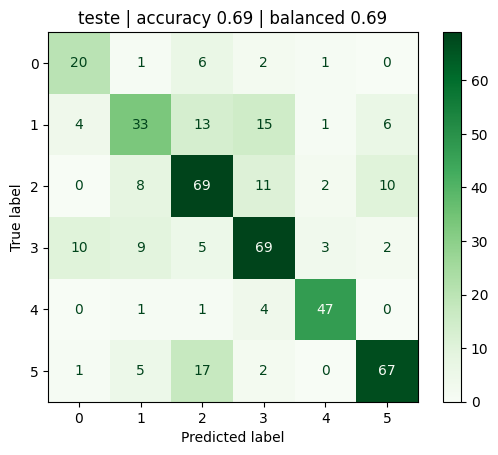


Classification Report (teste):
              precision    recall  f1-score   support

           0       0.57      0.67      0.62        30
           1       0.58      0.46      0.51        72
           2       0.62      0.69      0.65       100
           3       0.67      0.70      0.69        98
           4       0.87      0.89      0.88        53
           5       0.79      0.73      0.76        92

    accuracy                           0.69       445
   macro avg       0.68      0.69      0.68       445
weighted avg       0.69      0.69      0.68       445

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__n_ame
2. num__has_pmqr
3. num__has_mcr
4. num__has_ampc_adquirida
5. num__n_classes_adquiridas
6. num__n_genes_adquiridos
7. num__pct_adquiridos_plasmidial

--- Status de Cada Atributo no Pipeline ---
        Atributo_Preprocessado

array([2, 2, 4, 1, 1, 4, 5, 3, 2, 0, 1, 3, 1, 3, 5, 1, 1, 3, 3, 3, 2, 4,
       4, 3, 5, 3, 5, 4, 2, 5, 5, 3, 0, 5, 3, 4, 4, 1, 5, 3, 2, 2, 4, 3,
       1, 2, 3, 3, 4, 3, 5, 1, 0, 0, 2, 5, 4, 0, 3, 1, 3, 2, 2, 2, 3, 3,
       5, 4, 1, 5, 3, 4, 0, 2, 4, 5, 2, 1, 1, 3, 2, 5, 5, 5, 5, 3, 3, 3,
       2, 3, 1, 5, 4, 5, 1, 5, 5, 0, 2, 5, 5, 4, 2, 4, 1, 5, 2, 1, 2, 2,
       3, 2, 3, 2, 2, 0, 2, 5, 0, 4, 0, 1, 3, 5, 2, 2, 3, 2, 2, 3, 1, 3,
       5, 3, 2, 0, 5, 5, 0, 3, 1, 2, 4, 5, 3, 2, 2, 5, 3, 5, 2, 5, 2, 1,
       1, 2, 2, 2, 5, 1, 1, 5, 3, 2, 2, 2, 2, 3, 2, 2, 4, 5, 2, 4, 5, 4,
       1, 2, 2, 2, 2, 4, 3, 3, 4, 1, 2, 2, 4, 3, 2, 5, 2, 1, 4, 5, 3, 0,
       3, 5, 0, 3, 1, 2, 1, 2, 4, 2, 1, 4, 2, 3, 0, 2, 5, 2, 2, 4, 2, 4,
       2, 2, 2, 4, 1, 4, 2, 0, 4, 2, 5, 1, 5, 3, 0, 0, 2, 1, 3, 3, 0, 0,
       2, 3, 1, 5, 4, 3, 5, 1, 5, 5, 2, 5, 4, 2, 3, 4, 1, 2, 3, 3, 5, 3,
       3, 4, 3, 0, 5, 2, 5, 3, 3, 3, 2, 1, 1, 1, 0, 2, 2, 2, 5, 5, 3, 5,
       2, 3, 4, 3, 3, 5, 1, 2, 1, 2, 4, 3, 5, 2, 1,

In [7]:
cl = pd.read_csv(RAIZ / "data/processed/clusters_risco.csv", index_col=0)["cluster"]
df_train = pd.read_csv("../data/processed/df_estruturada/df_train_risco.csv", index_col=0).join(cl)
df_valid  = pd.read_csv("../data/processed/df_estruturada/df_valid_risco.csv",  index_col=0).join(cl)

X_COLS = ["n_ame", "has_pmqr", "has_mcr", "has_ampc_adquirida",
          "n_classes_adquiridas", "n_genes_adquiridos", "pct_adquiridos_plasmidial"]

clf = Classifier(df_train[X_COLS + ["cluster"]], 
                 target="cluster",
                 df_test=df_valid[X_COLS + ["cluster"]])

# "knn", "svm", "rf", "gbm", "nb", "nn"
metricas, y_pred = clf.classify("rf")        

clf.modelos_["rf"].predict(df_valid[X_COLS])
